<h1>Overview</h1>

Financial markets are inherently uncertain, but that uncertainty itself has patterns. 
While stock returns appear random, their *volatility* (the magnitude of price swings) 
is predictable - it clusters. Calm periods follow calm periods, turbulent periods 
follow turbulent periods. This is called "volatility clustering."

Traditional statistical models assume constant volatility, which fails to capture 
this reality. This is where GARCH (Generalized Autoregressive Conditional 
Heteroskedasticity) comes in.

GARCH is a time series model specifically designed to forecast time-varying volatility. 
It recognizes that:
- Large returns (+ or -) tend to be followed by more large returns
- Small returns tend to be followed by more small returns

The GARCH(1,1) model I use has three components:
- **ω (omega)**: Long-run average volatility
- **α (alpha)**: How much yesterday's shock affects today's volatility
- **β (beta)**: How persistent volatility is over time

Formula:
$$
    \sigma^2_{t} = \omega + \sum^q_{i=1}\alpha\epsilon^2_{t-1} + \sum^p_{i=1}\beta\sigma^2_{t-1}
$$

<h2>Data and Libraries Importation</h2>

In [1]:
import pandas as pd
import numpy as np

import yfinance as yf

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from arch import arch_model
from sklearn.metrics import mean_squared_error, mean_absolute_error

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
ticker = 'AAPL'
start = '2015-01-01'
end = '2025-12-30'

Downloading Apple (AAPL) closing prices from 2015 to end of 2025, then calculating daily percentage returns.<br>
When using arch model, it gives convergence error if the values are very small. So, avoiding that issue, I'm multiplying the return with 100 to get it in percentage format.

In [3]:
df = yf.download(tickers=ticker, start=start, end=end, timeout=25)['Close']

df['ret'] = df.pct_change() * 100

df = df.dropna()

[*********************100%***********************]  1 of 1 completed


In [4]:
df.head()

Ticker,AAPL,ret
Date,,
2015-01-05,23.532715,-2.817216
2015-01-06,23.534939,0.009451
2015-01-07,23.864948,1.402211
2015-01-08,24.781891,3.842215
2015-01-09,24.808472,0.107259


<h2>Data Exploration</h2>

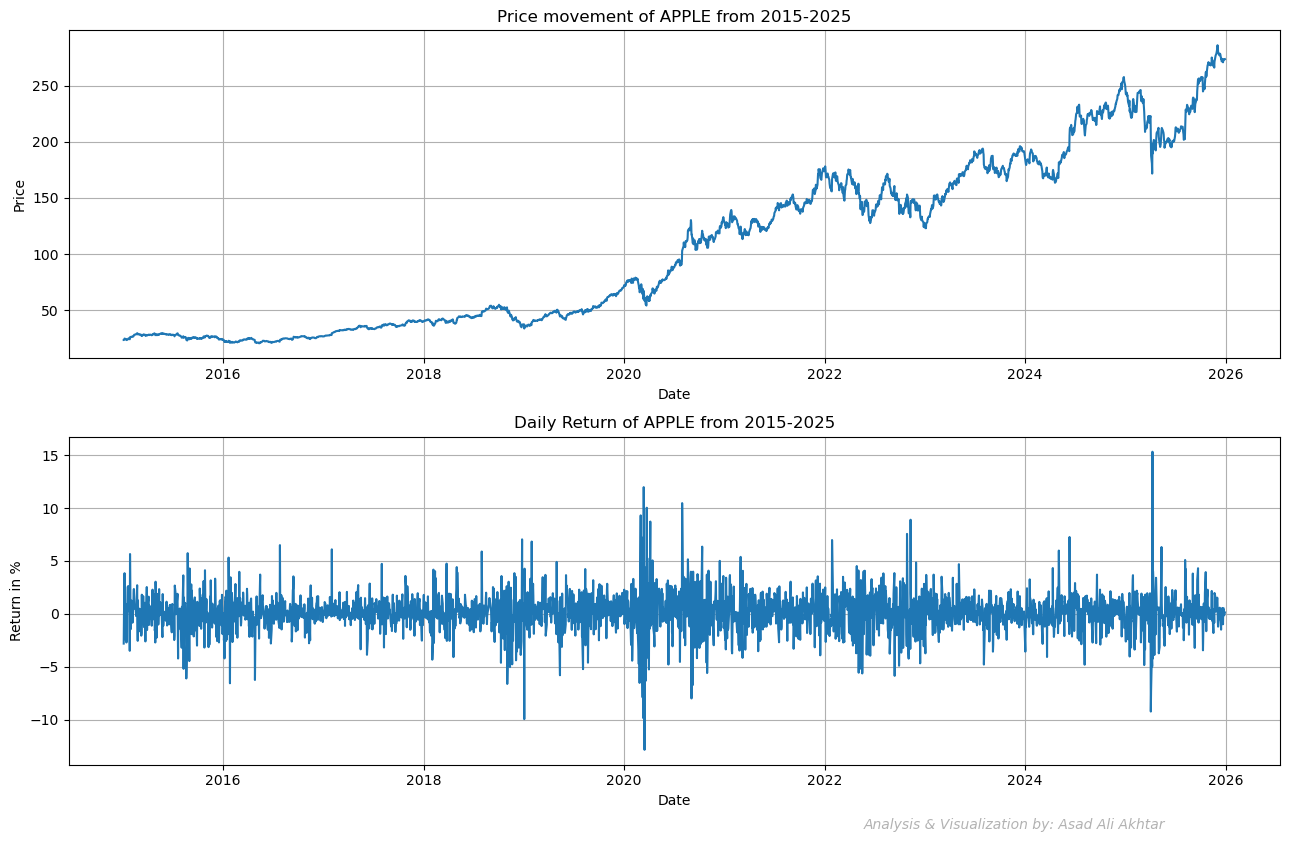

In [5]:
fig, ax = plt.subplots(2, 1, figsize=(13,9))
sns.lineplot(data=df['AAPL'], ax=ax[0])
ax[0].set_title('Price movement of APPLE from 2015-2025')
ax[0].set_ylabel('Price')
ax[0].grid()

sns.lineplot(data=df['ret'], ax=ax[1])
ax[1].set_title('Daily Return of APPLE from 2015-2025')
ax[1].set_ylabel('Return in %')
ax[1].grid();

fig.text(0.9, 0.02, 'Analysis & Visualization by: Asad Ali Akhtar', 
         fontsize=10, 
         color='gray', 
         ha='right', 
         va='bottom', 
         alpha=0.6, 
         fontstyle='italic')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

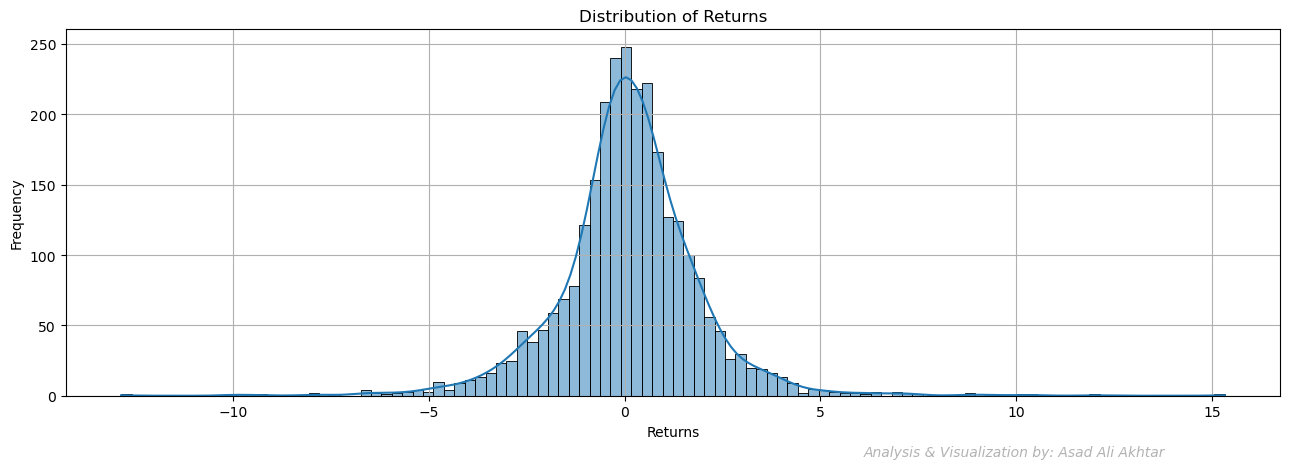

In [6]:
plt.figure(figsize=(13,5))
sns.histplot(data=df['ret'], kde=True)
plt.title('Distribution of Returns')
plt.xlabel('Returns')
plt.ylabel('Frequency')
plt.grid()

plt.gcf().text(0.9, 0.02, 'Analysis & Visualization by: Asad Ali Akhtar', 
               fontsize=10, 
               color='gray', 
               ha='right', 
               va='bottom', 
               alpha=0.6, 
               fontstyle='italic')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [7]:
print(f'Daily Volatility of APPLE stock over the time period of 2015-2025: {df['ret'].std():.4f}')

Daily Volatility of APPLE stock over the time period of 2015-2025: 1.8177


In [8]:
print(f'Annual Volatility of APPLE stock over the time period of 2015-2025: {df['ret'].std()*np.sqrt(252):.4f}')

Annual Volatility of APPLE stock over the time period of 2015-2025: 28.8556


We have computed daily and annual volatility. But these are single figures, which means that volatility is constant over that period, but in reality, it's not.<br>
To check how the volatility changes over time, I'll compute 50 days rolling volatility.

In [9]:
rolling_50d_vol = df['ret'].rolling(window=50).std().dropna()

In [10]:
rolling_50d_vol

Date
2015-03-17    1.796765
2015-03-18    1.741754
2015-03-19    1.748623
2015-03-20    1.757522
2015-03-23    1.686647
                ...   
2025-12-22    1.085560
2025-12-23    1.080855
2025-12-24    1.081644
2025-12-26    1.081021
2025-12-29    1.072352
Name: ret, Length: 2714, dtype: float64

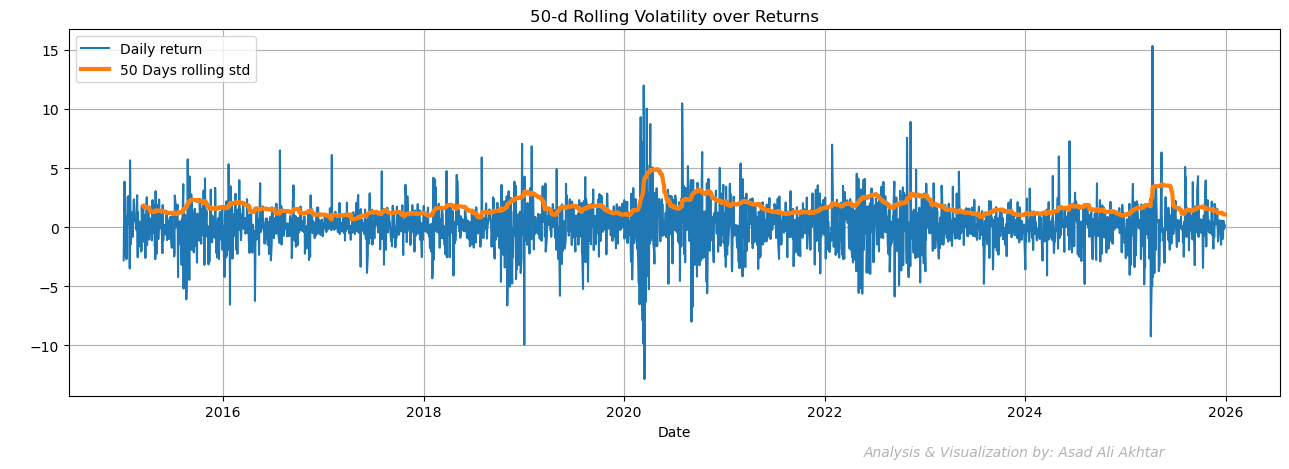

In [11]:
plt.figure(figsize=(13,5))
sns.lineplot(data=df['ret'], label='Daily return')
sns.lineplot(data=rolling_50d_vol, linewidth=3, label='50 Days rolling std')
plt.title('50-d Rolling Volatility over Returns')
plt.ylabel(' ')
plt.grid()
plt.legend()

plt.gcf().text(0.9, 0.02, 'Analysis & Visualization by: Asad Ali Akhtar', 
               fontsize=10, 
               color='gray', 
               ha='right', 
               va='bottom', 
               alpha=0.6, 
               fontstyle='italic')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In Garch model, we try to model and detect volatility clustering. High volatility is cause by high jumps in returns, either positive or negative. If we want to assess positive and negative returns together, we have to take square of them so that positives and negatives don't cancel each other.

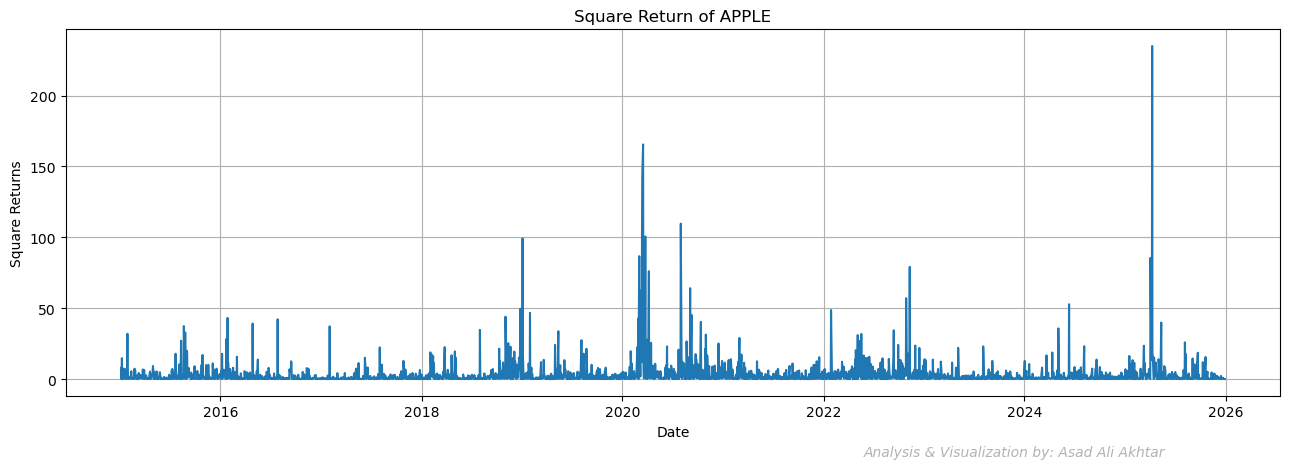

In [12]:
plt.figure(figsize=(13,5))
sns.lineplot(data=(df['ret']**2))
plt.title('Square Return of APPLE')
plt.ylabel('Square Returns')
plt.grid()

plt.gcf().text(0.9, 0.02, 'Analysis & Visualization by: Asad Ali Akhtar', 
               fontsize=10, 
               color='gray', 
               ha='right', 
               va='bottom', 
               alpha=0.6, 
               fontstyle='italic')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

I'll plot `correlogram` to check the autocorrelation in the time series of square returns.

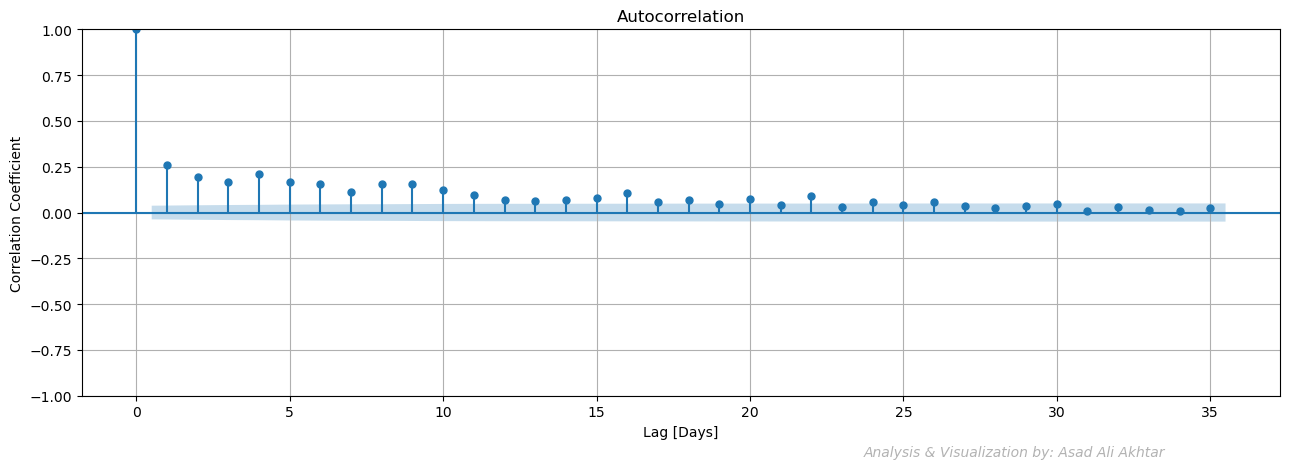

In [13]:
fig, ax = plt.subplots(figsize=(13,5))
plot_acf(df['ret']**2, ax=ax)
ax.set_ylabel('Correlation Coefficient')
ax.set_xlabel('Lag [Days]')
ax.grid()

fig.text(0.9, 0.02, 'Analysis & Visualization by: Asad Ali Akhtar', 
         fontsize=10, 
         color='gray', 
         ha='right', 
         va='bottom', 
         alpha=0.6, 
         fontstyle='italic')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

By looking at the `ACF-Plot`, we can see that there is a significant autocorrelation till `Lag` 9.<br>
There is another plot to verify that, `PACF-Plot`

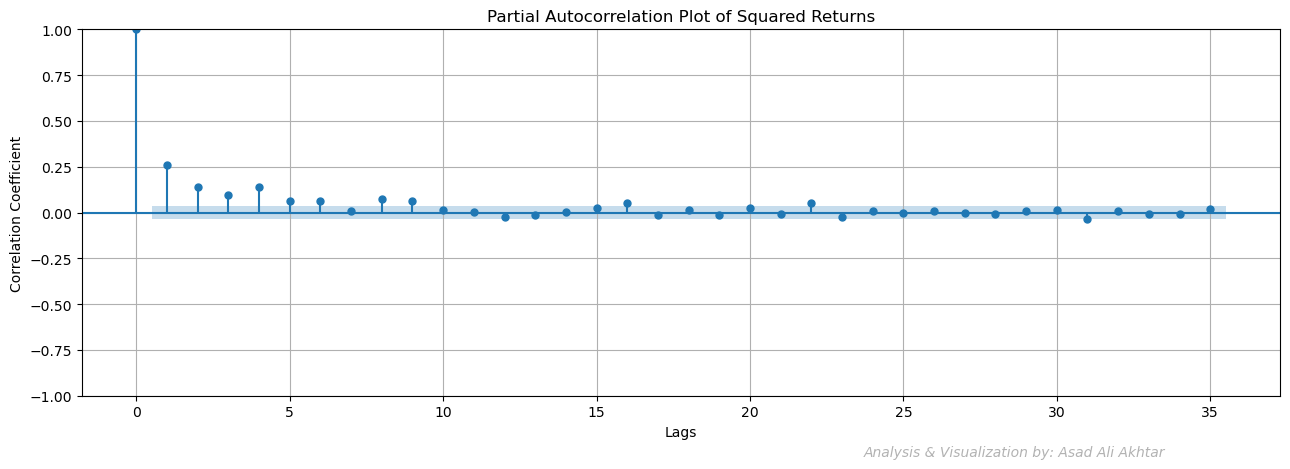

In [14]:
fig, ax = plt.subplots(figsize=(13,5))
plot_pacf(df['ret']**2, ax=ax)
ax.set_title('Partial Autocorrelation Plot of Squared Returns')
ax.set_ylabel('Correlation Coefficient')
ax.set_xlabel('Lags')
ax.grid()

fig.text(0.9, 0.02, 'Analysis & Visualization by: Asad Ali Akhtar', 
         fontsize=10, 
         color='gray', 
         ha='right', 
         va='bottom', 
         alpha=0.6, 
         fontstyle='italic')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('Partial_Autocorrelation_Plot_of_Squared_Returns.jpg')
plt.show()

As it is visible in the plot that we have autocorrelation in our time series. We can apply `Garch model` to model and forcast volatility.<br>
There are some statistical test with made sure that we don't make any mistake in interpreting *ACF* and *PACF* plots. One of them is `ARCH LM Test`.

In [15]:
# ARCH LM Test
arch_test = het_arch(df['ret'], nlags=10)

print("ARCH LM Test Results:")
print(f"LM Statistic: {arch_test[0]:.4f}")
print(f"P-value: {arch_test[1]:.4f}")

ARCH LM Test Results:
LM Statistic: 349.4771
P-value: 0.0000


The **Null Hypothesis** of this test is: `No ARCH effect`. As the p-values is *significant*, we can reject the null hypothesis. And it verify our *ACF* and *PACF* plot.

<h2>Train_Test Split</h2>

I'm splitting data for model training and testing. I'm selecting **80%** of data for `train` and **20%** for `test`.

In [16]:
split_point = int(len(df['ret']) * 0.8)

In [17]:
df_train = df['ret'].iloc[:split_point]
print('Train data shape:', df_train.shape)
df_train.tail()

Train data shape: (2210,)


Date
2023-10-09    0.845133
2023-10-10   -0.335222
2023-10-11    0.790391
2023-10-12    0.506127
2023-10-13   -1.029291
Name: ret, dtype: float64

<h2>Model Iteration</h2>

We cannot apply *Garch* directly to the return series. We can apply it on the residuals of some other model. For this purpose, I'm using `Constant-Mean` model to create residuals and apply garch on that.<br>
Applying `Garch(1,1)`. Using `normal` distribution. There are many other option like `Student's-t`, `skew-t`, etc, based on the return distribution.<br>
I've already used latter and the `AIC` and `BIC` score is not satisfactory as compared to normal.

In [18]:
model = arch_model(
    df_train,
    p=1,
    q=1,
    mean='Constant',
    dist='normal'
).fit(disp=0)

print('Model type:', type(model))

model.summary()

Model type: <class 'arch.univariate.base.ARCHModelResult'>


<class 'statsmodels.iolib.summary.Summary'>
"""
                     Constant Mean - GARCH Model Results                      
==============================================================================
Dep. Variable:                    ret   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -4260.18
Distribution:                  Normal   AIC:                           8528.36
Method:            Maximum Likelihood   BIC:                           8551.16
                                        No. Observations:                 2210
Date:                Fri, Feb 13 2026   Df Residuals:                     2209
Time:                        15:18:05   Df Model:                            1
                               Mean Model                               
========================================================================
                 coef    std err          t      P>|t|  95.0% Conf. Int.
------------------------------------------------------------------------
mu             0.1820  3.501e-02      5.198  2.020e-07 [  0.113,  0.251]
                             Volatility Model                             
==========================================================================
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
omega          0.1506  4.583e-02      3.287  1.012e-03 [6.082e-02,  0.240]
alpha[1]       0.1153  2.246e-02      5.132  2.865e-07 [7.126e-02,  0.159]
beta[1]        0.8398  2.785e-02     30.149 1.118e-199   [  0.785,  0.894]
==========================================================================

Covariance estimator: robust
"""

We should use Garch model that satisfy *PACF* plot lags, in our case, it's 4. So we should have used *Garch(4,4)* model, which i did but the coefficients of our `omega`, `alpha`, and `beta` were not significant.<br>
But as you can see, they are significant in the case of *Garch(1,1)*.

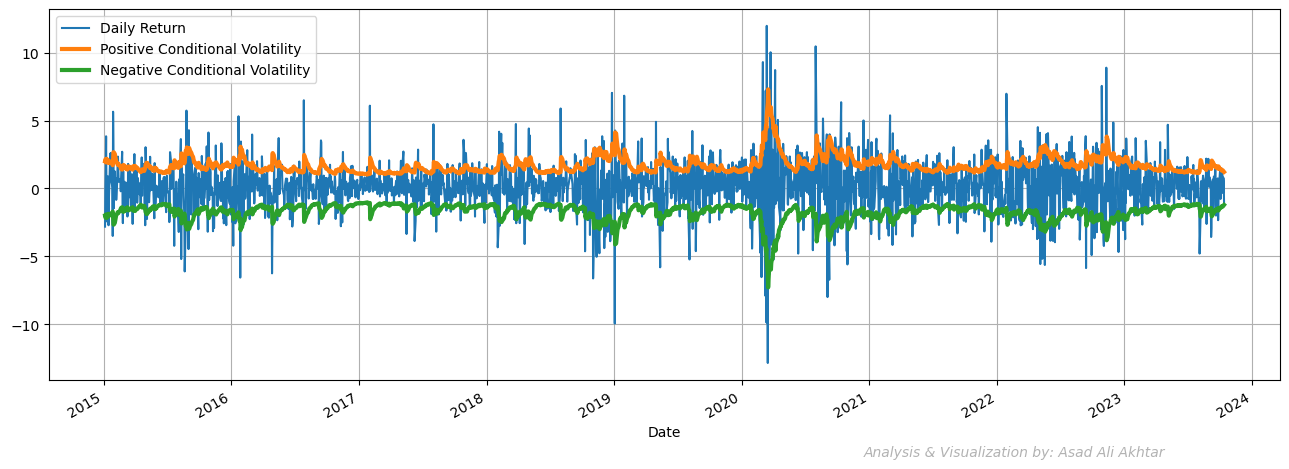

In [19]:
plt.figure(figsize=(13,5))
df_train.plot(label='Daily Return')
model.conditional_volatility.plot(label='Positive Conditional Volatility', linewidth=3)
(-model.conditional_volatility).plot(label='Negative Conditional Volatility', linewidth=3)
plt.grid()
plt.legend()

plt.gcf().text(0.9, 0.02, 'Analysis & Visualization by: Asad Ali Akhtar', 
               fontsize=10, 
               color='gray', 
               ha='right', 
               va='bottom', 
               alpha=0.6, 
               fontstyle='italic')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('Train_Con_vol_plot.jpg')
plt.show()

The plot shows that our Garch model captures volatility properly of the train data.

In [20]:
df_test = df['ret'].iloc[split_point:]

In [21]:
print('Shape of test data:', df_test.shape)

Shape of test data: (553,)


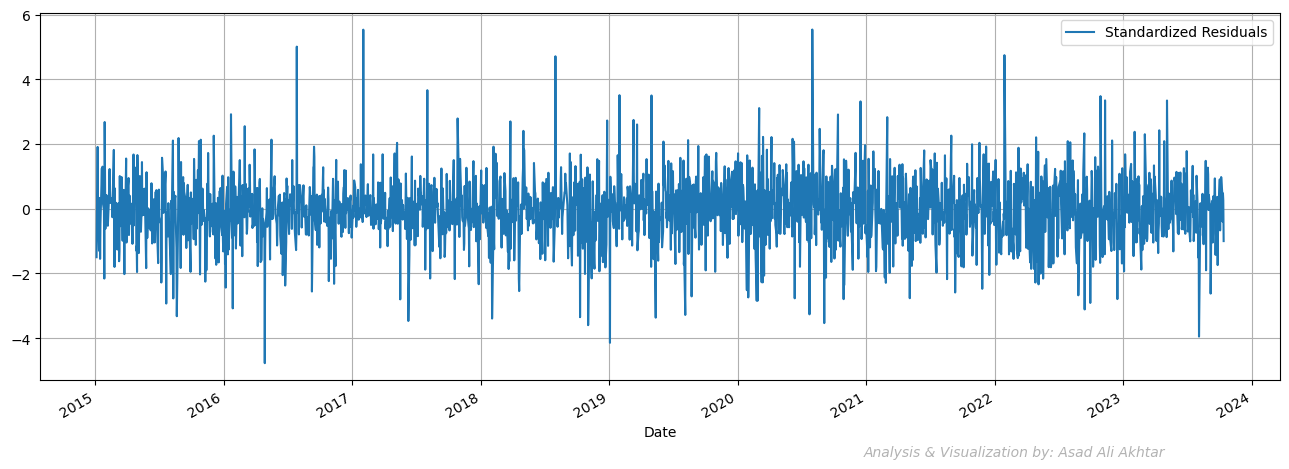

In [22]:
plt.figure(figsize=(13,5))
model.std_resid.plot(label='Standardized Residuals')
plt.grid()
plt.legend()

plt.gcf().text(0.9, 0.02, 'Analysis & Visualization by: Asad Ali Akhtar', 
               fontsize=10, 
               color='gray', 
               ha='right', 
               va='bottom', 
               alpha=0.6, 
               fontstyle='italic')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('Residual_plot.jpg')
plt.show()

The standardized residuals are also `random`, without any trend.

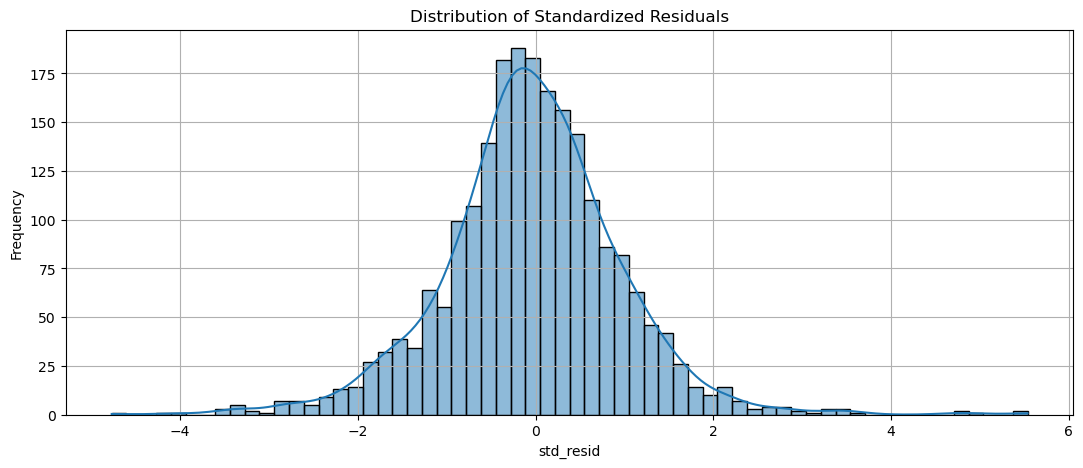

In [23]:
plt.figure(figsize=(13,5))
sns.histplot(model.std_resid, kde=True)
plt.title('Distribution of Standardized Residuals')
plt.ylabel('Frequency')
plt.grid()

Now we'll see if there is any Autocorrelation in standardized residuals. As before, I'll square the standardized residuals so that positives and negative don't cancel each other.

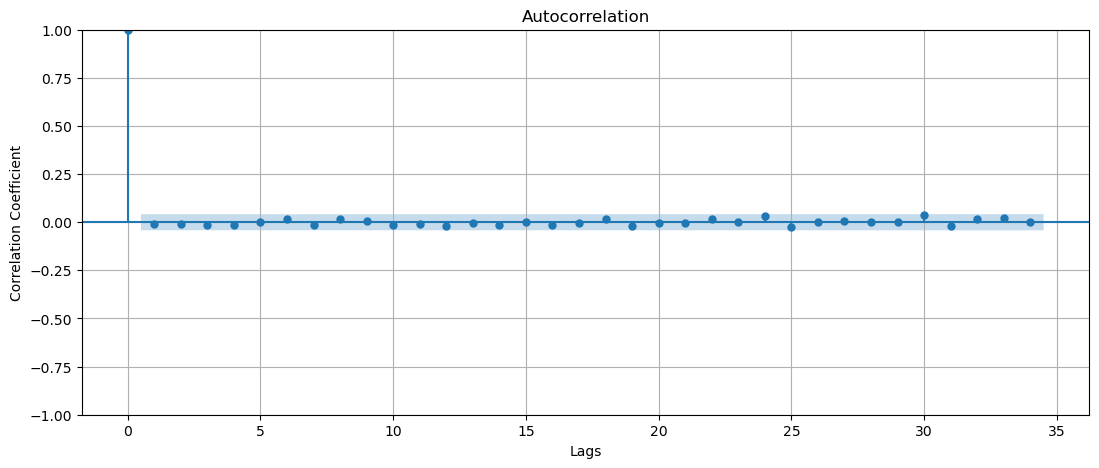

In [24]:
fig, ax = plt.subplots(figsize=(13,5))
plot_acf(model.std_resid**2, ax=ax)
ax.set_ylabel('Correlation Coefficient')
ax.set_xlabel('Lags')
ax.grid();

The plot shows that is not autocorrelation in standardized residuals.

We'll check that with a test as well. We'll use `ljungbox` test.

In [25]:
# Test if standardized residuals are white noise
lb_test_resid = acorr_ljungbox(model.std_resid, lags=10, return_df=True)
print("Ljung-Box Test on Standardized Residuals:")
print(lb_test_resid)

# Test if squared standardized residuals have no ARCH effects
lb_test_sq = acorr_ljungbox(model.std_resid**2, lags=10, return_df=True)
print("\nLjung-Box Test on Squared Standardized Residuals:")
print(lb_test_sq)

Ljung-Box Test on Standardized Residuals:
      lb_stat  lb_pvalue
1    0.002346   0.961367
2    2.870253   0.238085
3    4.252668   0.235441
4    4.466891   0.346491
5    5.360745   0.373457
6    5.425572   0.490498
7   10.003181   0.188393
8   12.507589   0.129953
9   17.015417   0.048475
10  17.024423   0.073825

Ljung-Box Test on Squared Standardized Residuals:
     lb_stat  lb_pvalue
1   0.273197   0.601195
2   0.536080   0.764877
3   0.990384   0.803579
4   1.412380   0.842040
5   1.412604   0.922930
6   1.863409   0.931822
7   2.411120   0.933640
8   2.873007   0.942072
9   2.939267   0.966654
10  3.275210   0.974186


The **Null Hypothesis** of this test is: `No Autocorrelation`. As the p-values are not significant, we *cannot reject* null hypthesis.

Now for testing our model, I'll using `Walk Forward Validation` with `expanding window`.

In [26]:
preditctions = []

test_size = int(len(df['ret']) * 0.2)

for i in range(test_size):
    y_train = df['ret'].iloc[: -(test_size-i)]

    model = arch_model(y_train, p=1, q=1, dist='normal').fit(disp=0)

    next_pred = model.forecast(horizon=1, reindex=False).variance.iloc[0,0] ** 0.5

    preditctions.append(next_pred)

y_test_wfv = pd.Series(preditctions, index=df['ret'].tail(test_size).index)

In [27]:
y_test_wfv.head()

Date
2023-10-17    1.209290
2023-10-18    1.227865
2023-10-19    1.230132
2023-10-20    1.198895
2023-10-23    1.293151
dtype: float64

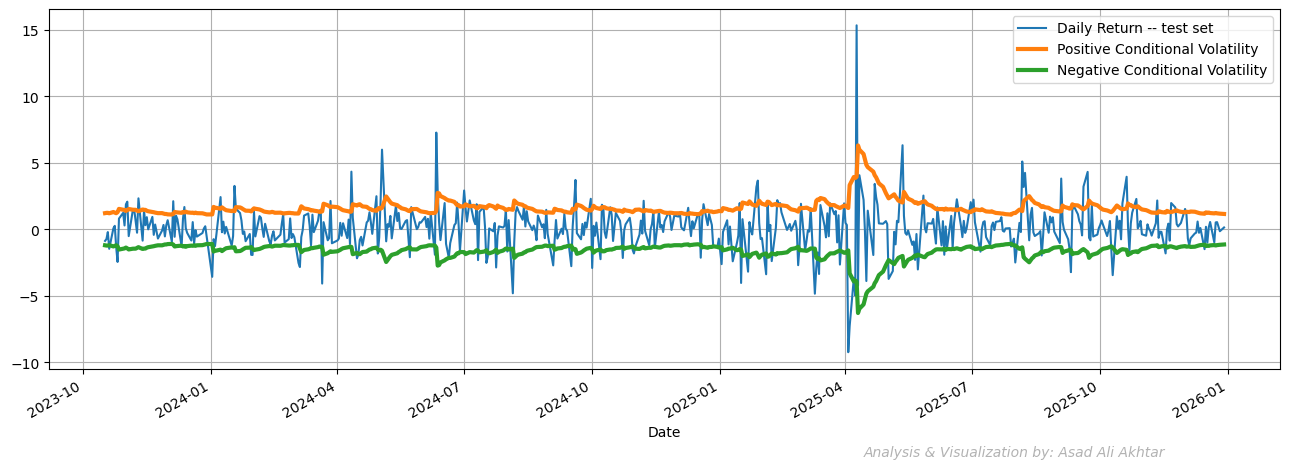

In [28]:
fig = plt.figure(figsize=(13,5))  # Store the figure
ax = df['ret'].tail(test_size).plot(label='Daily Return -- test set')
y_test_wfv.plot(label='Positive Conditional Volatility', linewidth=3, ax=ax)
(-y_test_wfv).plot(label='Negative Conditional Volatility', linewidth=3, ax=ax)
plt.grid()
plt.legend()

fig.text(0.9, 0.02, 'Analysis & Visualization by: Asad Ali Akhtar',
    fontsize=10,
    color='gray',
    ha='right',
    va='bottom',
    alpha=0.6,
    fontstyle='italic')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('Test_Con_vol_plot.jpg', dpi=100, bbox_inches='tight')
plt.show()

The above plot shows our model fit volatility on the test data. It captures well, high volatile and low volatitle regimes.<br>
Now I'll compare my model with benchmark to see if it works.

In [29]:
realized_vol = df['ret'].tail(test_size).abs()

In [30]:
comparison_df = pd.concat([realized_vol, y_test_wfv], axis=1).dropna()
comparison_df.columns = ['Realized', 'Predicted']

rmse = np.sqrt(mean_squared_error(comparison_df['Realized'],
                                  comparison_df['Predicted']))

mae = mean_absolute_error(comparison_df['Realized'],
                          comparison_df['Predicted'])

In [31]:
print(f'Garch RMSE: {rmse:.4f}')
print(f'Garch MAE: {mae:.4f}')

Garch RMSE: 1.3404
Garch MAE: 1.0098


In [32]:
rolling_vol = df['ret'].rolling(50).std().shift(1).tail(test_size)

benchmark_df = pd.concat([realized_vol, rolling_vol], axis=1).dropna()
benchmark_df.columns = ['Realized', 'Rolling']

rmse_roll = np.sqrt(mean_squared_error(benchmark_df['Realized'],
                                       benchmark_df['Rolling']))

mae_roll = mean_absolute_error(benchmark_df['Realized'],
                                benchmark_df['Rolling'])

print(f'Rolling RMSE: {rmse_roll:.4f}')
print(f'Rolling MAE: {mae_roll:.4f}')

Rolling RMSE: 1.4266
Rolling MAE: 1.0302


Comparison Result:
<ul>
<li>GARCH RMSE: 1.340</li>
<li>Rolling RMSE: 1.427</li>
<li><b>GARCH is 6% better!</b></li>
</ul>

- `GARCH MAE`: 1.010  
- `Rolling MAE`: 1.030
- **GARCH is 2% better!**

GARCH outperforms the naive benchmark, justifying the complexity!

<h2>Conclusion</h2>

This project successfully demonstrated:
<ol>
    <li>Apple returns exhibit volatility clustering</li>
    <li>GARCH(1,1) with normal-distribution captures this clustering</li>
    <li>Model passes all diagnostic tests</li>
    <li>Out-of-sample forecasts outperform simple rolling volatility by 6%</li>
</ol>